# Lab 2: Regression Analysis

## Aim
To implement and compare linear, multiple linear, and logistic regression models.

## Datasets Used

1. Linear Regression - Boston Housing Dataset
2. Multiple Linear Regression - Student Performance Dataset
3. Logistic Regression - Breast Cancer Dataset

## Objective

- Implement Linear Regression using mathematical formulas.
- Implement Multiple Linear Regression using mathematical formulas.
- Implement Logistic Regression using the sigmoid function and gradient descent.
- Evaluate regression models using MAE, RMSE and R² Score.
- Evaluate classification using Accuracy, Precision, Recall and F1 Score.
- Visualize the model results.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PART A — LINEAR REGRESSION

Load Boston Housing data

In [105]:
housing = pd.read_csv("datasets/housing.csv")

In [106]:
housing.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [107]:
housing.shape

(506, 14)

In [108]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [109]:
housing.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [110]:
housing.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [111]:
x = housing[["rm"]].values.flatten()
y = housing["medv"].values

In [113]:
np.random.seed(42)

indices = np.random.permutation(len(x))
x = x[indices]
y = y[indices]

In [114]:
split = int(0.8 * len(x))

In [115]:
x_train = x[:split]
y_train = y[:split]

In [116]:
x_test = x[split:]
y_test = y[split:]

In [117]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 404
Testing samples: 102


## Feature scaling
This is important because Gradient Descent works much better when values are reasonably scaled.

In [118]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train_scaled = (x_train - mean) / std
x_test_scaled = (x_test - mean) / std

In [119]:
theta0 = 0
theta1 = 0

In [120]:
eta = 0.01

In [121]:
iterations = 1000

In [122]:
def predict_linear(x, theta0, theta1):
    return theta0 + theta1 * x

In [123]:
def compute_cost(x, y, theta0, theta1):
    m = len(y)

    predictions = predict_linear(x, theta0, theta1)

    error = predictions - y

    cost = (1 / (2 * m)) * np.sum(error ** 2)

    return cost

## Gradient Descent

In [124]:
def train_linear_regression(x,y,eta,iterations):
    m = len(y)
    
    theta0 = 0
    theta1 = 0
    
    cost_history = []
    
    for i in range(iterations):
        predictions = predict_linear(x, theta0, theta1)
        
        error = predictions - y
        
        d_theta0 = (1/m) * np.sum(error)
        d_theta1 = (1/m) * np.sum(error*x)
        
        theta0 = theta0 - eta*d_theta0
        theta1 = theta1 - eta*d_theta1
        
        cost = compute_cost(x,y,theta0,theta1)
        
        cost_history.append(cost)
        
    return theta0, theta1, cost_history

In [125]:
theta0, theta1, cost_history = train_linear_regression(
    x_train_scaled,
    y_train,
    eta,
    iterations
)

In [126]:
print("Theta 0:", theta0)
print("Theta 1:", theta1)

Theta 0: 22.498781132866736
Theta 1: 6.218008835000731


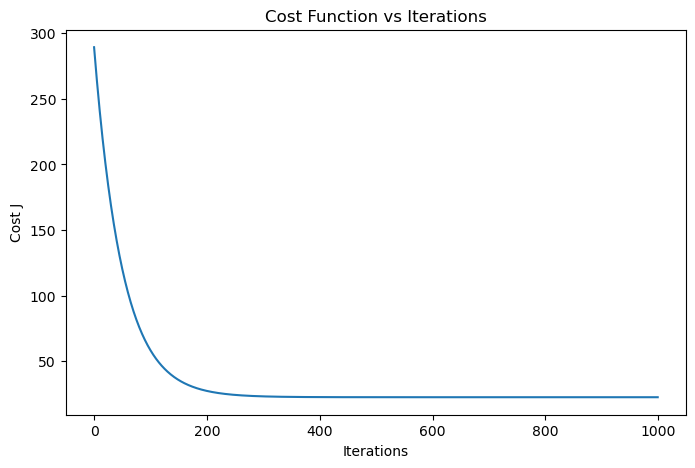

In [127]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost J")
plt.title("Cost Function vs Iterations")

plt.show()

## Make Prediction

In [128]:
y_pred = predict_linear(
    x_test_scaled,
    theta0,
    theta1
)

In [129]:
print("Actual:", y_test[:10])
print("Predicted:", y_pred[:10])

Actual: [14.1 50.  34.9 19.8 23.7 20.2 13.5 23.2 38.7 15.3]
Predicted: [24.64660617 29.05442719 30.57157944 17.97652261 14.65494669 24.53887938
 19.35901638 20.39139809 38.50745274 11.06405379]


# MAE

In [130]:
mae = np.mean(np.abs(y_test - y_pred))

print("MAE:", mae)

MAE: 4.384128443879296


# RMSE

In [131]:
rmse = np.sqrt(
    np.mean((y_test - y_pred) ** 2)
)

print("RMSE:", rmse)

RMSE: 6.237610289214736


# R^2 Score

In [134]:
ss_res = np.sum((y_test - y_pred) ** 2)

ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("R^2 Score:", r2)

R^2 Score: 0.5587752919765483


# Visualization

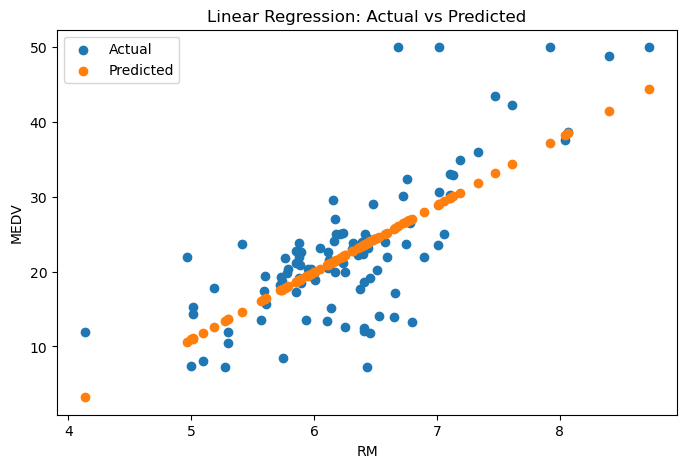

In [135]:
plt.figure(figsize=(8,5))

plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred, label="Predicted")

plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Linear Regression: Actual vs Predicted")

plt.legend()
plt.show()